# 01 · 데이터 정제 (Data Cleaning)

> **로또 6/45 & 연금복권 — 정직한 데이터 사이언스 스터디**
> Part 1 of 4 · *Cleaning → EDA → Hypothesis Testing → Prediction Backtest*

이 프로젝트의 원본 데이터 `lottery.db`는 스프레드시트 워크북을 그대로 SQLite로 덤프한 파일입니다.
값(당첨번호) 자체는 대체로 멀쩡하지만, **스키마는 엉망**입니다. 실무에서 흔히 마주치는 형태이며,
분석에 들어가기 전에 반드시 정리해야 합니다.

This notebook documents three concrete kinds of dirt and the pipeline that removes them:

1. **Phantom columns** — 399 leftover `extra_*` columns from trailing spreadsheet cells.
2. **Type/encoding corruption** — prize amounts stored as TEXT with a mojibake currency suffix.
3. **Orphan sheet-dump tables** — 8 spreadsheet tabs dumped with generic `col_N` headers.

정제 로직은 재사용 가능한 `src/lotto_ds/cleaning.py`에 있으며, 노트북은 그 결과를
*before / after*로 시각화합니다. **원본 DB는 절대 수정하지 않습니다.**

In [1]:
import sys
from pathlib import Path

# Make the project package importable when running from notebooks/.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd

from src.lotto_ds import RAW_DB, CLEAN_DB, viz
from src.lotto_ds import cleaning

viz.apply_style()
pd.set_option("display.max_columns", 30)
print("raw DB :", RAW_DB.name, "· exists:", RAW_DB.exists())

raw DB : lottery.db · exists: True


## 1. 원본 상태 진단 (Profiling the raw dump)

`draw_results` 테이블부터 봅니다. 열이 몇 개일까요?

In [2]:
raw = cleaning.read_raw_draw_results()
print(f"draw_results: {raw.shape[0]:,} rows × {raw.shape[1]:,} columns")

phantom_cols = [c for c in raw.columns if c.startswith("extra_")]
real_cols = [c for c in raw.columns if not c.startswith("extra_")]
print(f"  · 실제 의미 있는 열 (real)     : {len(real_cols)}")
print(f"  · 유령 열 (phantom extra_*)   : {len(phantom_cols)}")

# 유령 열 중 실제로 값이 들어있는 것은 극소수 — 스프레드시트 우측의 흩어진 잔여 셀입니다.
phantom_with_data = [c for c in phantom_cols if raw[c].notna().any()]
print(f"  · 그중 값이 조금이라도 있는 열 : {len(phantom_with_data)} (나머지는 전부 NULL)")

draw_results: 1,230 rows × 419 columns
  · 실제 의미 있는 열 (real)     : 20
  · 유령 열 (phantom extra_*)   : 399
  · 그중 값이 조금이라도 있는 열 : 61 (나머지는 전부 NULL)


열의 **93%가 유령 열**입니다 (399 / 419). 이제 유령 열의 결측 패턴을 시각적으로 확인합니다.

findfont: Failed to find font weight 600, now using 700.


findfont: Failed to find font weight 600, now using 700.


findfont: Failed to find font weight 600, now using 700.


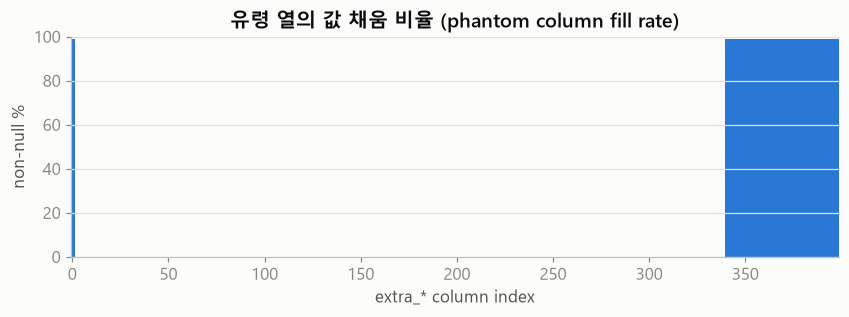

In [3]:
import matplotlib.pyplot as plt
import numpy as np

fill_rate = raw[phantom_cols].notna().mean().values * 100
fig, ax = plt.subplots(figsize=(9, 2.6))
ax.bar(range(len(fill_rate)), fill_rate, color=viz.CAT[0], width=1.0)
ax.set_title("유령 열의 값 채움 비율 (phantom column fill rate)")
ax.set_xlabel("extra_* column index")
ax.set_ylabel("non-null %")
ax.set_ylim(0, 100)
ax.margins(x=0)
viz.savefig(fig, "01_phantom_fill_rate.png")
plt.show()

거의 모든 유령 열이 0%에 붙어 있습니다. 스프레드시트 편집 중 생긴 흔적일 뿐,
어떤 것도 실제 변수가 아닙니다 → **전부 삭제 대상**.

## 2. 타입/인코딩 오염 — 당첨금 열 (Prize columns)

1등 당첨금 총액은 숫자가 아니라 **문자열**로 저장돼 있고, 통화 접미사가 깨져 있습니다 (mojibake).

In [4]:
prize_sample = pd.read_sql(
    "SELECT draw_no, prize_1st_total, prize_1st_count, prize_1st_per_person "
    "FROM draw_results WHERE draw_no IN (2, 3, 100, 1000, 1229) ORDER BY draw_no",
    cleaning._connect(RAW_DB),
)
print(prize_sample.to_string(index=False))
print()
print("dtype of prize_1st_total :", raw["prize_1st_total"].dtype, "(object = 문자열)")
print("예시 원본 값 (raw repr)   :", repr(raw["prize_1st_total"].iloc[1]))  # '2002006800��'

 draw_no prize_1st_total  prize_1st_count  prize_1st_per_person
       2     2002006800원              1.0                   NaN
       3     2000000000원              1.0                   NaN
     100     3315315525원              4.0                   NaN
    1000     1246819620원             22.0                   7.0
    1229             NaN              NaN                   NaN

dtype of prize_1st_total : str (object = 문자열)
예시 원본 값 (raw repr)   : '2002006800원'


`'2002006800��'` — 끝의 `��`는 "원"이 인코딩 과정에서 깨진 것입니다.
또한 최근 회차(1229 등)는 당첨금이 **아직 채워지지 않아 NULL**입니다 — 이는 *진짜 결측*이므로
0으로 위조하지 않고 NULL로 보존합니다.

`parse_krw_amount()`는 선두 숫자만 안전하게 추출합니다:

In [5]:
for raw_val in ["2002006800��", "0�", "1,234,567원", "", None]:
    print(f"  {raw_val!r:>28}  ->  {cleaning.parse_krw_amount(raw_val)}")

                '2002006800��'  ->  2002006800
                          '0�'  ->  0
                  '1,234,567원'  ->  1234567
                            ''  ->  None
                          None  ->  None


## 3. 고아 시트 테이블 (Orphan sheet-dump tables)

DB에는 `draw_results` / `pension_results` 외에도 스프레드시트 탭이 그대로 덤프된 테이블들이 있습니다.
열 이름이 `col_0, col_1, ...`처럼 의미가 없고, 신뢰할 스키마가 없습니다.

In [6]:
all_tables = cleaning.list_raw_tables()
orphans = [t for t in all_tables if t in cleaning.ORPHAN_TABLES]
print("전체 테이블:", all_tables)
print()
print("고아 테이블 (버릴 대상):")
for t in orphans:
    cols = pd.read_sql(f"SELECT * FROM {t} LIMIT 0", cleaning._connect(RAW_DB)).columns.tolist()
    print(f"  · {t:<20} {len(cols)} cols  e.g. {cols[:4]}")
print()
print("→ 이런 통계는 신뢰하지 않고, 원본 당첨번호에서 직접 재계산합니다 (notebook 02~03).")

전체 테이블: ['consecutive_stats', 'draw_results', 'empty_sheet', 'number_freq_dist', 'number_stats', 'pension_results', 'prediction_accuracy', 'prediction_accuracy_pension_v3', 'prediction_accuracy_v3', 'prize_calc_logic', 'sum_freq_dist', 'sum_odd_even', 'verification']

고아 테이블 (버릴 대상):
  · consecutive_stats    13 cols  e.g. ['col_0', 'col_1', 'col_2', 'col_3']
  · empty_sheet          31 cols  e.g. ['col_0', 'col_1', 'col_2', 'col_3']
  · number_freq_dist     29 cols  e.g. ['col_0', 'col_1', 'col_2', 'col_3']
  · number_stats         150 cols  e.g. ['col_0', 'col_1', 'col_2', 'col_3']
  · prize_calc_logic     14 cols  e.g. ['col_0', 'col_1', 'col_2', 'col_3']
  · sum_freq_dist        22 cols  e.g. ['col_0', 'col_1', 'col_2', 'col_3']
  · sum_odd_even         8 cols  e.g. ['col_0', 'col_1', 'col_2', 'col_3']
  · verification         76 cols  e.g. ['col_0', 'col_1', 'col_2', 'col_3']

→ 이런 통계는 신뢰하지 않고, 원본 당첨번호에서 직접 재계산합니다 (notebook 02~03).


## 4. 정제 파이프라인 실행 (Run the pipeline)

`build_clean_db()`가 위 세 가지를 모두 처리하고, 검증을 거쳐 정규화된 clean DB를 만듭니다.

In [7]:
report = cleaning.build_clean_db()
rep = report.as_dict()

summary = pd.DataFrame(
    [
        ("원본 draw_results 열 수", rep["raw_draw_results_columns"], "419"),
        ("삭제한 유령 열", rep["phantom_columns_dropped"], "399"),
        ("버린 고아 테이블", len(rep["orphan_tables_dropped"]), "8"),
        ("로또 회차 수", rep["lotto_rows"], f"{rep['lotto_draw_range']}"),
        ("중복 회차 / 시퀀스 공백 / 범위이탈", rep["lotto_duplicate_draws"], "0 / 0 / 0"),
        ("당첨금 파싱 성공 / 결측", rep["prizes_parsed"], f"{rep['prizes_missing']} missing"),
        ("연금 본추첨 회차", rep["pension_draws"], f"{rep['pension_main_rows']} rows"),
    ],
    columns=["항목 (metric)", "value", "detail"],
)
summary

,항목 (metric),value,detail
0,원본 draw_results 열 수,419,419
1,삭제한 유령 열,399,399
2,버린 고아 테이블,8,8
3,로또 회차 수,1230,"[1, 1230]"
4,중복 회차 / 시퀀스 공백 / 범위이탈,0,0 / 0 / 0
5,당첨금 파싱 성공 / 결측,1218,12 missing
6,연금 본추첨 회차,322,322 rows


## 5. Before / After

clean DB는 5개의 tidy 테이블로 정규화됩니다.

In [8]:
import sqlite3

with sqlite3.connect(str(CLEAN_DB)) as conn:
    clean_tables = pd.read_sql(
        "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name", conn
    )["name"].tolist()

before_after = pd.DataFrame({
    "": ["테이블 수 (tables)", "draw_results 열 수", "당첨금 타입", "통계 신뢰도"],
    "BEFORE (raw)": [len(all_tables), raw.shape[1], "TEXT+mojibake", "고아 시트 (불명)"],
    "AFTER (clean)": [len(clean_tables), 9, "Int64 (KRW)", "원본에서 재계산"],
})
print(before_after.to_string(index=False))
print()
print("clean 테이블:", clean_tables)

                  BEFORE (raw) AFTER (clean)
  테이블 수 (tables)            13             5
draw_results 열 수           419             9
          당첨금 타입 TEXT+mojibake   Int64 (KRW)
          통계 신뢰도    고아 시트 (불명)      원본에서 재계산

clean 테이블: ['draw_numbers', 'draws', 'pension_bonus', 'pension_draws', 'prizes']


### tidy long-form 미리보기
EDA에서 번호별 집계를 쉽게 하기 위해 당첨번호를 long 형태로도 저장했습니다.

In [9]:
draws = cleaning.load_clean("draws")
draw_numbers = cleaning.load_clean("draw_numbers")
prizes = cleaning.load_clean("prizes")

print("draws (wide):")
print(draws.tail(3).to_string(index=False))
print("\ndraw_numbers (tidy long):")
print(draw_numbers.head(8).to_string(index=False))
print(f"\n→ {len(draws):,} draws × 6 = {len(draw_numbers):,} long rows")

draws (wide):
 draw_no  draw_date  win1  win2  win3  win4  win5  win6  bonus
    1228 2026-06-13    24    29    30    31    35    44      1
    1229 2026-06-20    12    13    29    34    37    42     16
    1230 2026-06-27     3     8     9    22    28    42     45

draw_numbers (tidy long):
 draw_no  draw_date  position  number
       1 2002-12-07         1      10
       1 2002-12-07         2      23
       1 2002-12-07         3      29
       1 2002-12-07         4      33
       1 2002-12-07         5      37
       1 2002-12-07         6      40
       2 2002-12-14         1       9
       2 2002-12-14         2      13

→ 1,230 draws × 6 = 7,380 long rows


## 6. 정제 결과 검증 (Validation)

파이프라인이 만든 clean DB가 실제로 신뢰 가능한지 assert로 확인합니다.
(동일 검증이 `tests/test_cleaning.py`에 회귀 테스트로도 존재합니다.)

In [10]:
assert not [c for c in draws.columns if c.startswith("extra_")], "phantom columns leaked"
assert draws["draw_no"].is_unique, "duplicate draws"
assert draws["draw_no"].tolist() == list(range(1, len(draws) + 1)), "sequence gap"
for c in cleaning.WIN_COLS:
    assert draws[c].between(1, 45).all(), f"{c} out of range"
assert (draws[cleaning.WIN_COLS].nunique(axis=1) == 6).all(), "duplicate numbers within a draw"
assert len(draw_numbers) == len(draws) * 6, "long form row count mismatch"
# Stored as INTEGER; SQLite has no nullable-int, so read-back is numeric float (not TEXT anymore).
assert pd.api.types.is_numeric_dtype(prizes["prize_1st_total_krw"]), "prize not numeric-typed"
assert (prizes["prize_1st_total_krw"].dropna() >= 0).all(), "negative prize parsed"

print("✅ 모든 검증 통과 — clean DB는 분석에 사용할 준비가 되었습니다.")
print("   다음: 02_eda — 번호 빈도·합계·홀짝 등 탐색적 분석.")

✅ 모든 검증 통과 — clean DB는 분석에 사용할 준비가 되었습니다.
   다음: 02_eda — 번호 빈도·합계·홀짝 등 탐색적 분석.
